In [5]:
import sklearn

import shap

X, y = shap.datasets.california(n_points=1000)

X100 =shap.utils.sample(X,100)

model = sklearn.linear_model.LinearRegression()

model.fit(X,y)

LinearRegression()

# **Examining the model coefficients**
The most common way of understanding a linear model is to examine the coefficients learned for each feature. These coefficients tell us how much the model output changes when we change each of the input features:

In [6]:
print("Model Coefficients")
for i in range(X.shape[1]):
    print( X.columns[i],"=", model.coef_[i].round(5))

Model Coefficients
MedInc = 0.42563
HouseAge = 0.01033
AveRooms = -0.1161
AveBedrms = 0.66385
Population = 3e-05
AveOccup = -0.26096
Latitude = -0.46734
Longitude = -0.46272


While coefficients are great for telling us what will happen when we change the value of an input feature, by themselves they are not a great way to measure the overall importance of a feature. This is because the value of each coefficient depends on the scale of the input features. If for example we were to measure the age of a home in minutes instead of years, then the coefficients for the HouseAge feature would become 0.0115 / (365∗24∗60) = 2.18e-8.

## complete picture using partial dependence plots

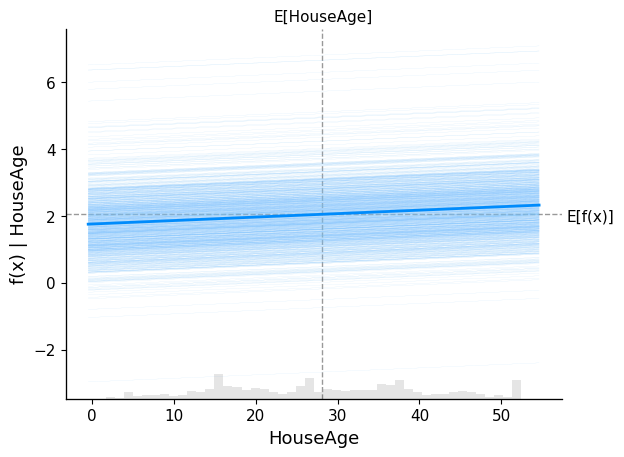

In [7]:
shap.partial_dependence_plot("HouseAge", model.predict, X, model_expected_value=True, feature_expected_value=True)

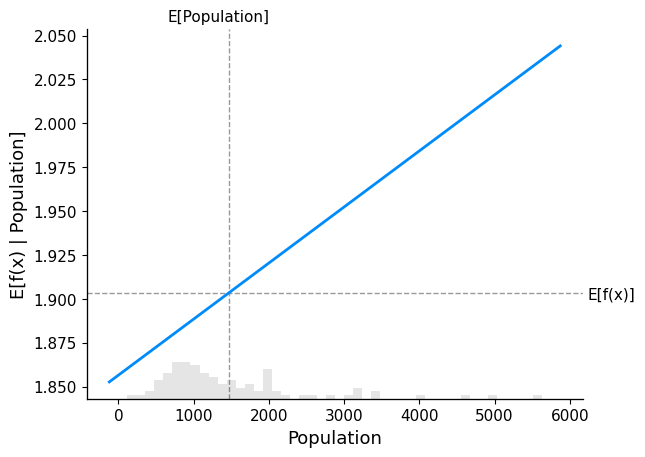

In [8]:
shap.partial_dependence_plot("Population", model.predict, X100,ice =False, model_expected_value=True, feature_expected_value=True)

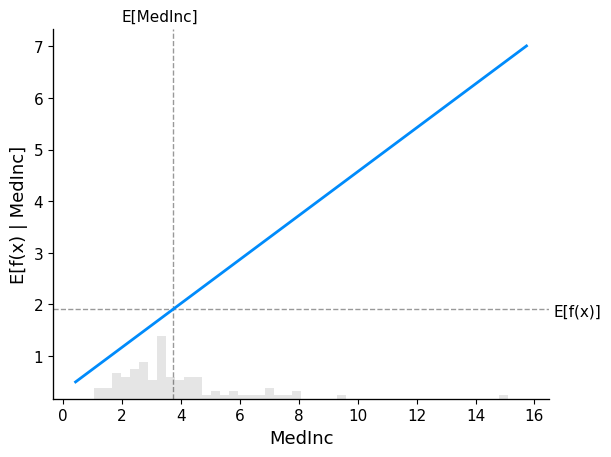

In [9]:
shap.partial_dependence_plot("MedInc",model.predict,X100,ice=False, model_expected_value=True, feature_expected_value=True)

The gray horizontal line in the plot above represents the expected value of the model when applied to the California housing dataset. The vertical gray line represents the average value of the median income feature. Note that the blue partial dependence plot line.

 We can consider this intersection point as the “center” of the partial dependence plot with respect to the data distribution. The impact of this centering will become clear when we turn to Shapley values next.

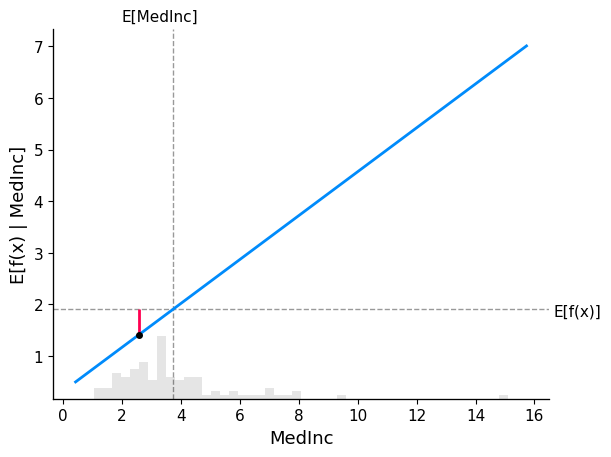

In [10]:
from shap.utils import sample
explainer = shap.Explainer(model.predict, X100)
shap_values = explainer(X)

# make a standard patrial dependence plot
sample_ind = 20
shap.partial_dependence_plot("MedInc", model.predict, X100, model_expected_value=True, feature_expected_value=True, ice= False, shap_values=shap_values[sample_ind : sample_ind +1,:])

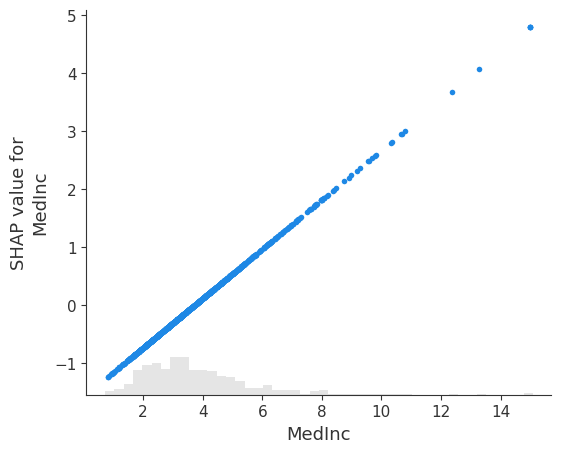

In [11]:
shap.plots.scatter(shap_values[:,"MedInc"])

### The additive nature of Shapley values

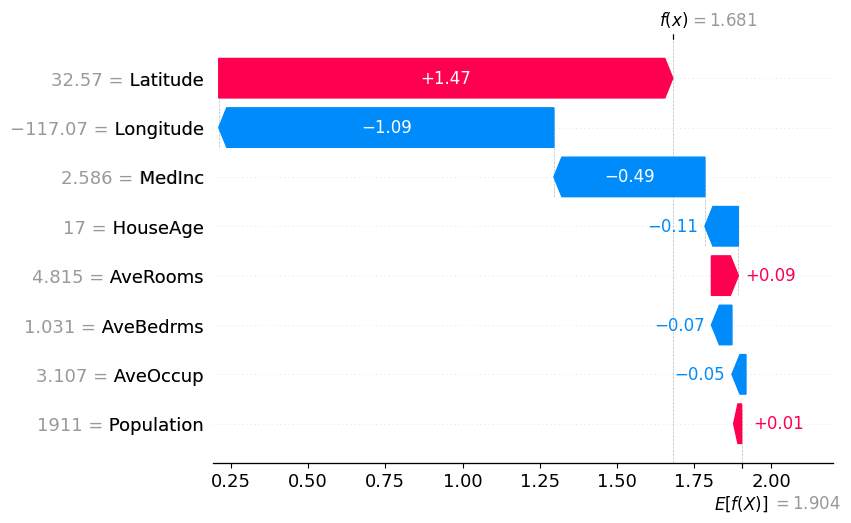

In [12]:
shap.plots.waterfall(shap_values[sample_ind],max_display=14)

## Explaining an additive regression model

The reason the partial dependence plots of linear models have such a close connection to SHAP values is because each feature in the model is handled independently of every other feature (the effects are just added together).

generalized additive models (GAMs)

In [13]:
#fit a GAM model to the data
!pip install interpret

ExactExplainer explainer: 1001it [00:10,  5.55it/s]                         


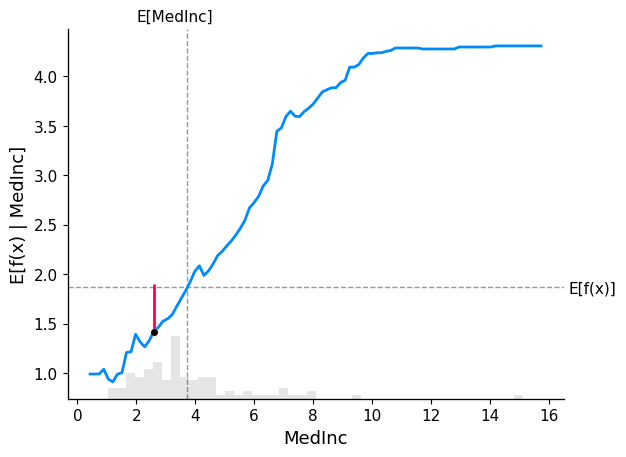

In [14]:
import interpret.glassbox

model_ebm = interpret.glassbox.ExplainableBoostingRegressor(interactions = 0)
model_ebm.fit(X,y)

# explain the GAM model with
explainer_ebm = shap.Explainer(model_ebm.predict, X100)
shap_values_ebm = explainer_ebm(X)

# make a standard partial dependence plot with a single SHAP value overlaid
fig, ax = shap.partial_dependence_plot("MedInc", model_ebm.predict, X100, model_expected_value=True,
                                       feature_expected_value=True, show = False,ice = False, shap_values=shap_values[sample_ind : sample_ind +1,:],)

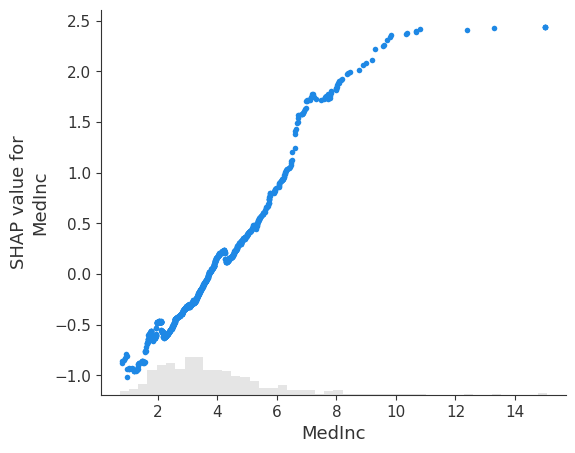

In [15]:
shap.plots.scatter(shap_values_ebm[:,"MedInc"])

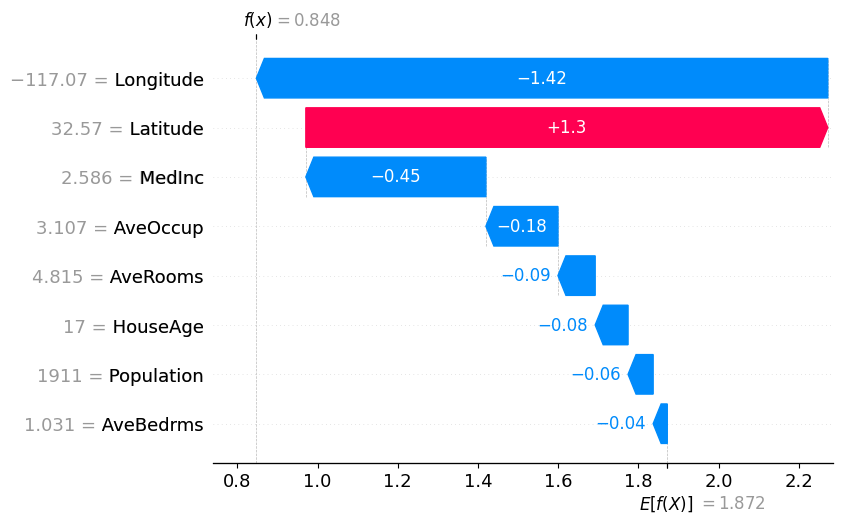

In [16]:
shap.plots.waterfall(shap_values_ebm[sample_ind])

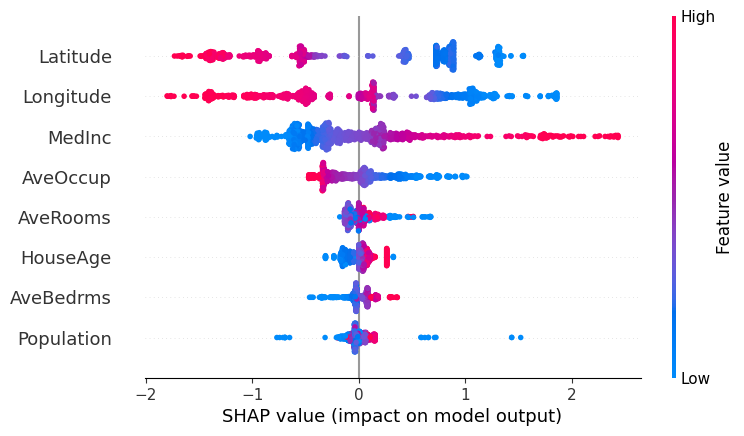

In [17]:
# the beeswarm plot displays SHAP values for each features across all examples
# with clors indicating how the SHAP values correlate with feature values
shap.plots.beeswarm(shap_values_ebm)

### Explaining a non-additive boosted tree model

In [18]:
import xgboost as xgb
model_xgb = xgb.XGBRegressor()
model_xgb.fit(X,y)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

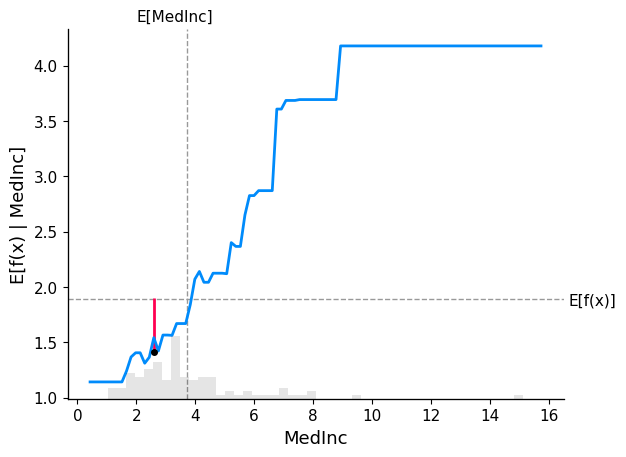

In [19]:
import xgboost
model_xgb = xgboost.XGBRegressor(n_estimators = 100, max_depth = 2).fit(X,y)

# explain the GAM model with SHAP
explainer_xgb = shap.Explainer(model_xgb)
shap_values_xgb = explainer_xgb(X)

#make a standard partial dependence plot with a single SHAP value overlaid
fig, ax = shap.partial_dependence_plot("MedInc", model_xgb.predict, X100, model_expected_value=True,
                                       feature_expected_value=True, show = False,ice = False, shap_values=shap_values[sample_ind : sample_ind +1,:],)




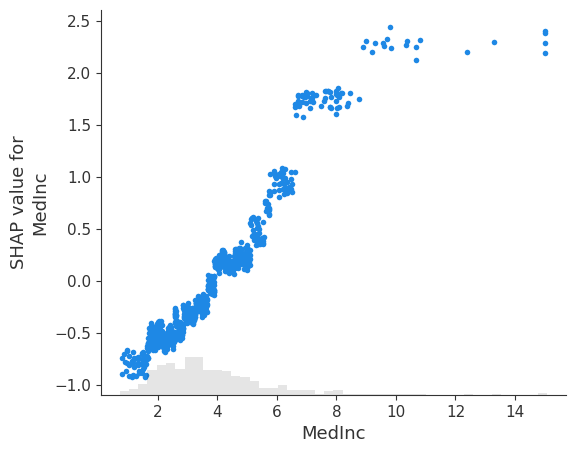

In [20]:
shap.plots.scatter(shap_values_xgb[:, "MedInc"])


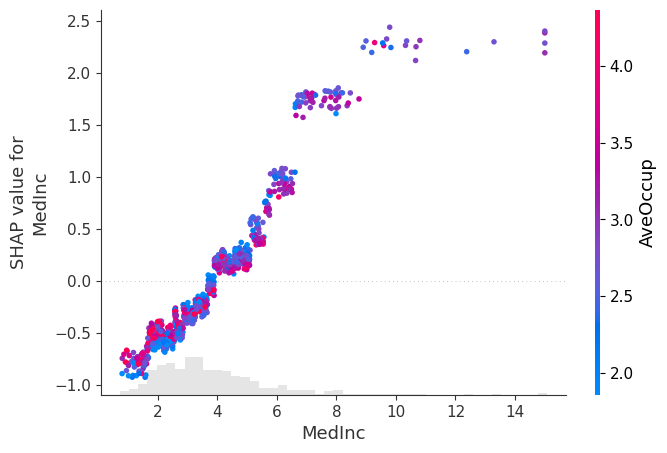

In [21]:
shap.plots.scatter(shap_values_xgb[:, "MedInc"], color=shap_values)


### A linear logistic regression model

In [22]:
# A classic adult census dataset data
X_adult, y_adult = shap.datasets.adult()

# a simple liner logistic model
model_adult = sklearn.linear_model.LogisticRegression(max_iter= 10000)
model_adult.fit(X_adult, y_adult)

def model_adult_proba(X):
    return model_adult.predict_proba(X)[:,1]


def model_adult_log_odds(x):
  p = model_adult.predict_log_proba(x)
  return p[:,1] - p[:,0]

Note that explaining the probability of a linear logistic regression model is not linear in the inputs.

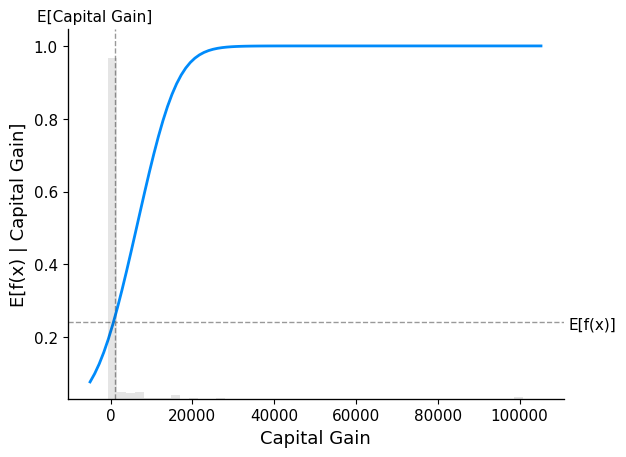

In [23]:
# make a stsandard partial dependence plot
sample_ind = 18
fig, ax = shap.partial_dependence_plot("Capital Gain", model_adult_proba, X_adult, model_expected_value=True,
                                       feature_expected_value=True, show = False, ice = False,)

If we use SHAP to explain the probability of a linear logistic regression model we see strong interaction effects. **This is because a linear logistic regression model is NOT additive in the probability space**

In [24]:
# compute the SHAP values for the linear model
background_adult = shap.maskers.Independent(X_adult, max_samples=100)
explainer_adult = shap.Explainer(model_adult_proba, background_adult)
shap_values_adult = explainer_adult(X_adult[:1000])

PermutationExplainer explainer: 1001it [00:58, 14.12it/s]


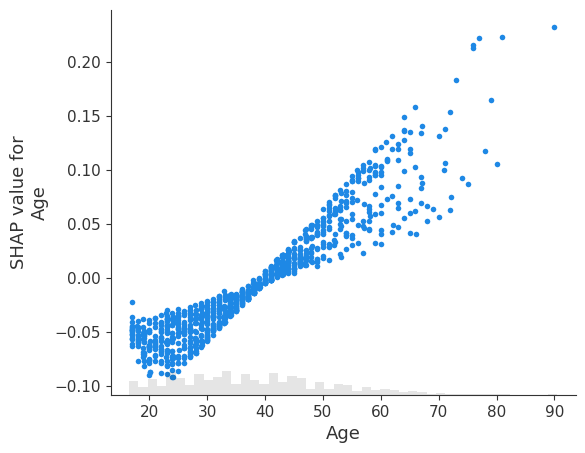

In [25]:
shap.plots.scatter(shap_values_adult[:, "Age"])


If we instead explain the log-odds output of the model we see a perfect linear relationship between the models inputs and the model’s outputs. It is important to remember what the units are of the model you are explaining, and that explaining different model outputs can lead to very different views of the model’s behavior.

In [26]:
# compute the SHAP values for the linear model
explainer_log_odds = shap.Explainer(model_adult_log_odds, background_adult)
shap_values_adult_log_odds = explainer_log_odds(X_adult[:1000])

PermutationExplainer explainer: 1001it [00:35, 20.37it/s]


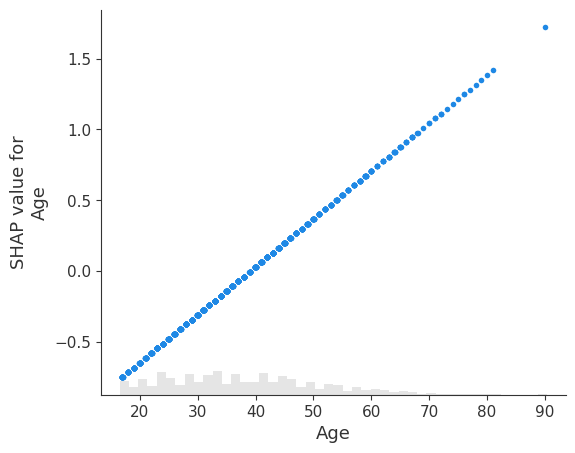

In [27]:
shap.plots.scatter(shap_values_adult_log_odds[:, "Age"])


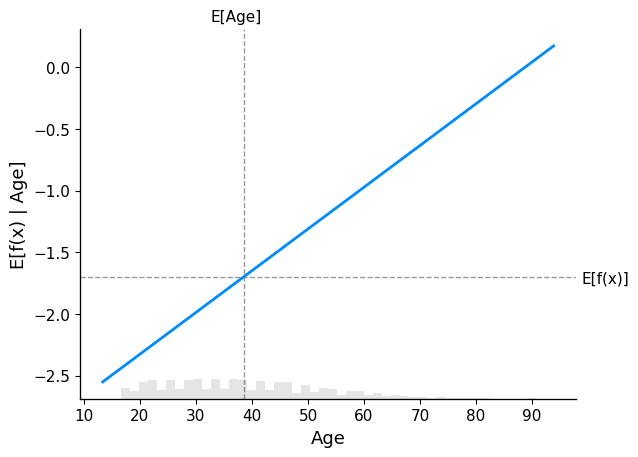

In [28]:
# make a standard partial dependence plot
sampl_ind = 18
fig, ax = shap.partial_dependence_plot("Age", model_adult_log_odds, X_adult, model_expected_value=True,
                                       feature_expected_value=True, show = False, ice = False,)

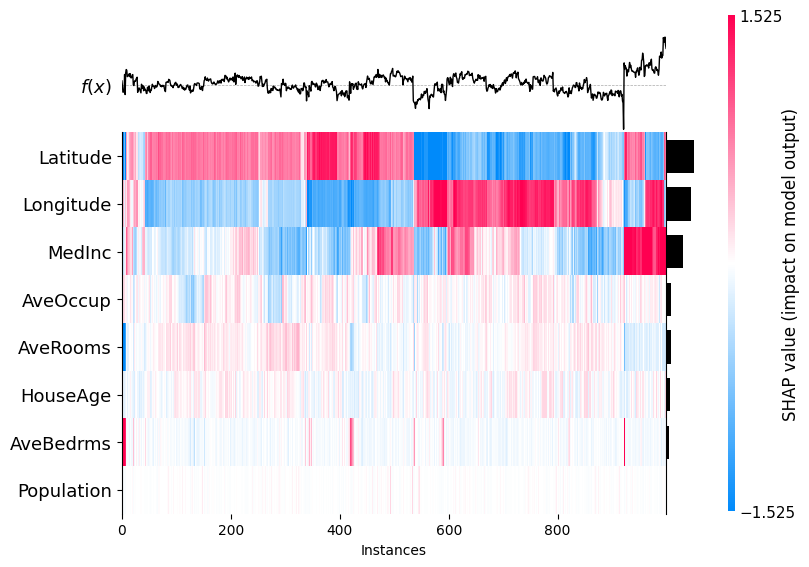

<Axes: xlabel='Instances'>

In [29]:
shap.plots.heatmap(shap_values[:1000])

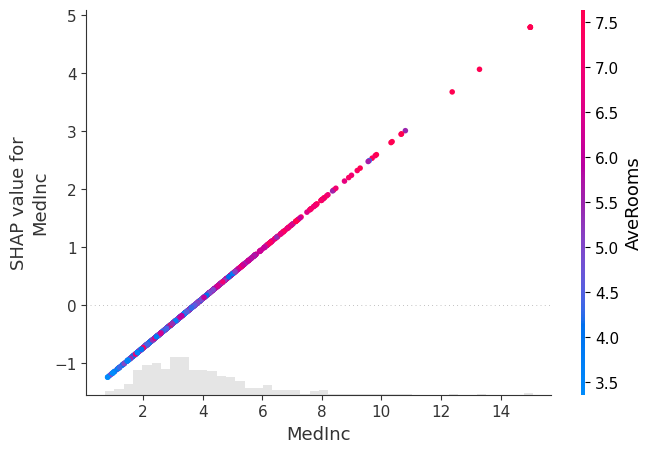

In [30]:
shap.plots.scatter(shap_values[:,"MedInc"],color=shap_values)

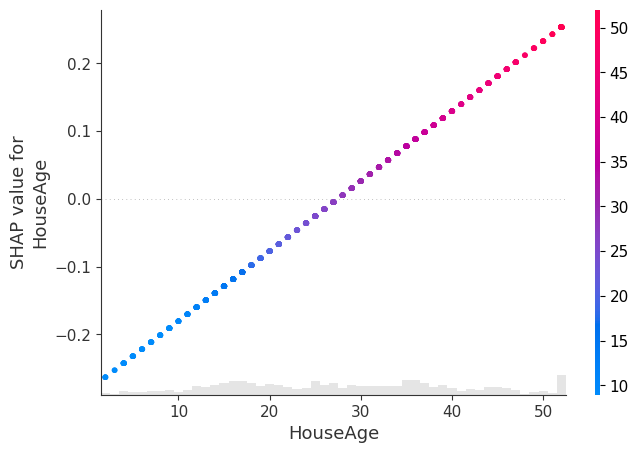

In [31]:
shap.plots.scatter(shap_values[:, "HouseAge"], color=shap_values.data[:, X.columns.get_loc("HouseAge")])

**Dealing with correlated features**

In [32]:
clustering = shap.utils.hclust(X, y)

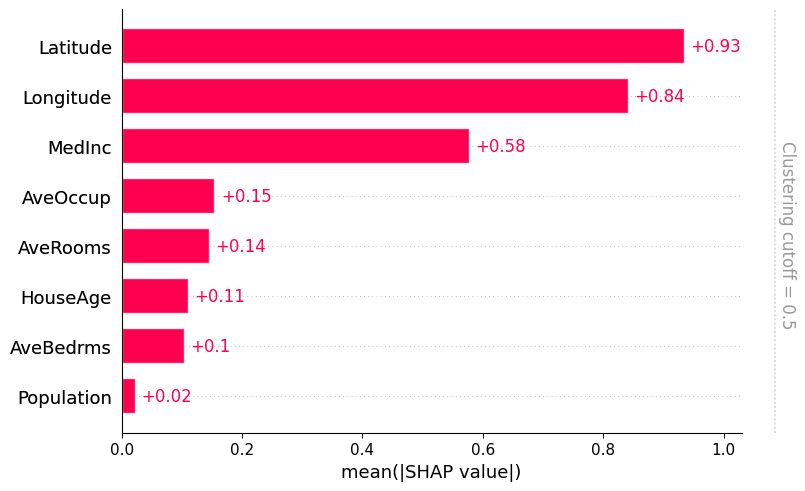

In [33]:
shap.plots.bar(shap_values, clustering=clustering)

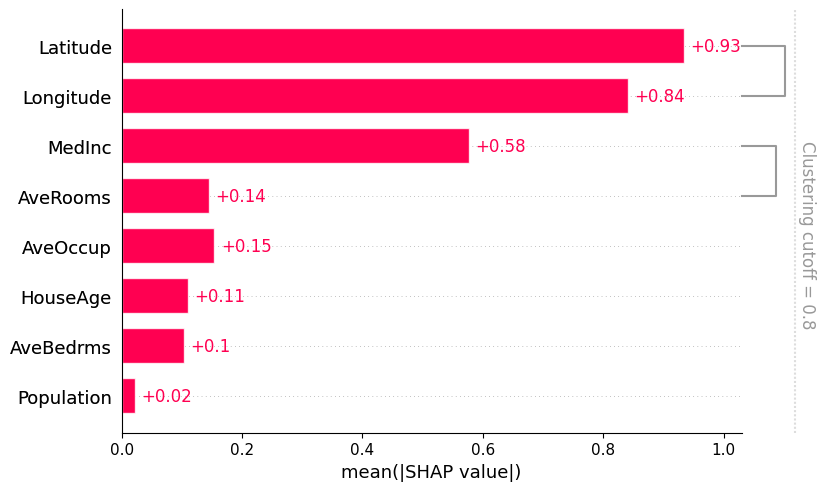

In [34]:
shap.plots.bar(shap_values, clustering = clustering, clustering_cutoff=0.8)

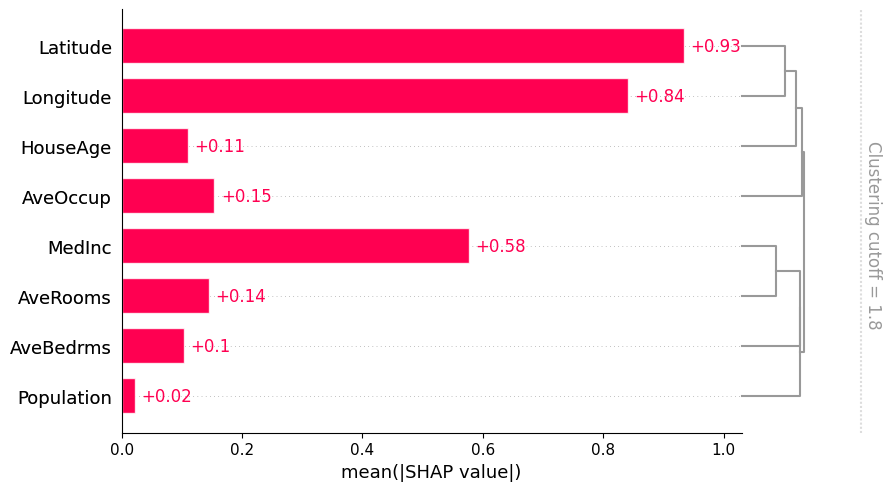

In [35]:
shap.plots.bar(shap_values, clustering=clustering,clustering_cutoff=1.8)

In [36]:
# Clear the datasets cache to resolve potential HfUriError due to corrupted metadata.
import datasets
print("Attempting to clear datasets cache...")
datasets.disable_caching()
# If you run into issues, you can also try datasets.delete_cache()
# Note: datasets.disable_caching() only disables caching for the current session.
# To permanently clear the cache, you would need to manually delete the cache directory (usually ~/.cache/huggingface/datasets)
# or use datasets.delete_cache(). However, for this persistent HfUriError, disabling for the current session may be enough.
print("Datasets caching disabled for this session. Please restart runtime and rerun cells.")

Attempting to clear datasets cache...
Datasets caching disabled for this session. Please restart runtime and rerun cells.


### Explaining a transformers NLP model


This demonstrates how SHAP can be applied to complex model types with highly structured inputs.

In [37]:
print('Upgrading datasets and huggingface_hub libraries to address HfUriError...')
!pip install --upgrade datasets huggingface_hub
print('Libraries upgraded. Please restart the runtime (Runtime -> Restart runtime) and then rerun all cells.')

Upgrading datasets and huggingface_hub libraries to address HfUriError...
Libraries upgraded. Please restart the runtime (Runtime -> Restart runtime) and then rerun all cells.


In [38]:
import datasets
import huggingface_hub

print("datasets:", datasets.__version__)
print("huggingface_hub:", huggingface_hub.__version__)

datasets: 5.0.0
huggingface_hub: 1.18.0


In [39]:
!pip install -U datasets huggingface_hub transformers

In [44]:
from google.colab import userdata
userdata.get('HF_TOKEN')
print("HF_TOKEN success applied")

HF_TOKEN success applied


In [45]:
import datasets
import numpy as np
import scipy as sp
import torch
import transformers
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# load a BERT sentiment analysis model
tokenizer = transformers.DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")
model = transformers.DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased-finetuned-sst-2-english"
).cuda()

# define a prediction function
def f(x):
  tv = torch.tensor([tokenizer.encode(v, padding="max_length", max_length=512, truncation = True) for v in x]).cuda()
  outputs = model(tv)[0].detach().cpu().numpy()
  scores = (np.exp(outputs).T / np.exp(outputs).sum(-1)).T
  val = sp.special.logit(scores[:,1]) # use one vs logit unit
  return val
# build an explainer using a token masker
explainer = shap.Explainer(f, tokenizer)

# explain the model's predictions on IMDB reviews
imdb_train = datasets.load_dataset("IMDB")["train"]
shap_values = explainer(imdb_train[:10], fixed_context=1, batch_size=2)



Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

HfUriError: Invalid HF URI 'hf://datasets/IMDB@e6281661ce1c48d982bc483cf8a173c1bbeb5d31/.huggingface.yaml'. Repository id must be 'namespace/name', got 'IMDB'.